<a href="https://colab.research.google.com/github/alvaroChico2408/Trabajo_Practico_Algoritmos_Optimizacion_AlvaroChicoCastellano/blob/main/Trabajo_Pr%C3%A1ctico_AlvaroChicoCastellano_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
**Nombre y Apellidos:** Álvaro Chico Castellano  <br>
**Github:** https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
**Cuaderno:** https://colab.research.google.com/drive/1RkqxTZCZFM7CV3srR0R36yKc_0wlXsXK#scrollTo=ixEJUwH_pv7M <br>
**Problema:**
>1. Sesiones de doblaje <br>

# **Descripción del problema:**  

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los datos son:

* Número de actores: 10
* Número de tomas : 30
* Actores/Tomas : https://bit.ly/36D8IuK

1 indica que el actor participa en la toma
0 en caso contrario






                                        

# **Modelo**
 # **1. ¿Cómo represento el espacio de soluciones?**

Analizando el problema vemos que hay unos límites implícitos en el propio enunciado. En el peor de los casos, suponiendo que solo se grabase una toma por día, podría realizarse en, como máximo, 30 días. Por otro lado, en el mejor de los casos, si se grabara el máximo posible de tomas diarias (6), podría realizarse en $\frac{30}{6} = 5$ días.

Por tanto, el espacio de soluciones estará formado por todas las posibles agrupaciones de las 30 tomas en un número de días comprendido entre 5 y 30, cumpliendo siempre que cada toma se asigne a un único día y que no haya más de 6 tomas por jornada.

### **Algoritmos propuestos**
Para la resolución de este problema haré uso de los algoritmos de GRASP y de Búsqueda Tabú. El objetivo final será resolver el problema propuesto haciendo uso de estos algoritmos y comparar el rendimiento y los resultados entre ellos, para determinar cuál ofrece mejores resultados y es más apropiado para la resolución del problema.

### **Representación de los datos de entrada**

Los datos de entrada vienen dados en el propio enunciado mediante una matriz binaria actor-toma. En ella, las filas representan las tomas y las columnas representan a cada uno de los actores. Un valor 1 indica que un actor participa en una determinada toma, mientras que un 0 indica que no participa.

### **Representación de las soluciones**

Para representar las posibles soluciones, utilizaré una lista de días. Consiste en una lista en la que cada índice representa un día de grabación; es decir, el índice 0 corresponde al día 1, el índice 1 al día 2, y así sucesivamente. Cada elemento de esa lista será, a su vez, otra lista que contendrá las tomas asignadas a ese día, teniendo siempre en cuenta que en un mismo día no podrán grabarse más de 6 tomas.

De esta forma, cada solución quedará representada como una agrupación de tomas por días, donde cada toma aparecerá una única vez dentro de toda la planificación.

Las soluciones tendrán una estructura similar a la siguiente:

```text
[
  [1, 4, 7, 12, 15],
  [2, 3, 8, 10, 20, 21],
  [5, 6, 9],
  [11, 13, 14, 16, 17, 18],
  [19, 22, 23, 24, 25, 26],
  [27, 28, 29, 30]
]
```
En este ejemplo, el primer elemento de la lista representa el día 1, el segundo elemento representa el día 2, y así sucesivamente.

Por ejemplo, la lista:
```text
[2, 3, 8, 10, 20, 21]
```
Indica que en el día 2 se grabarán esas seis tomas.  
Esta representación permitirá después calcular el coste de cada solución a partir de los actores distintos que deban acudir en cada día de grabación.

### **Justificación de la elección**

La elección de GRASP y Búsqueda Tabú se debe a que este problema es de tipo combinatorio, ya que existen muchas formas distintas de agrupar las tomas en días y no es sencillo encontrar directamente la mejor. Además, pequeñas modificaciones en la distribución de las tomas pueden hacer que el coste cambie bastante, por lo que resulta interesante utilizar algoritmos que permitan explorar distintas soluciones de forma eficiente.

En el caso de GRASP, su uso tiene sentido porque permite construir soluciones de forma progresiva, asignando tomas a los distintos días según un criterio de coste. En este problema, esa forma de trabajar encaja bien, ya que se puede ir decidiendo en qué día conviene colocar cada toma para intentar que coincidan actores y así reducir desplazamientos.

Por otro lado, la Búsqueda Tabú también resulta adecuada porque, una vez se tiene una solución inicial, es fácil generar soluciones vecinas realizando pequeños cambios, como mover una toma de un día a otro o intercambiar tomas entre días. De esta forma, el algoritmo puede ir mejorando la planificación y, gracias al uso de memoria, evitar quedarse atascado repitiendo siempre las mismas soluciones.

Además, el formato elegido para representar las soluciones, mediante una lista de días, también se ha escogido porque facilita bastante el trabajo con ambos algoritmos. Por un lado, permite construir la solución de manera clara en GRASP. Por otro, hace más sencillo definir movimientos entre soluciones en la Búsqueda Tabú. También ayuda a comprobar rápidamente si se cumple la restricción de un máximo de 6 tomas por día y a calcular el coste de cada solución.

# **2. ¿Cuál es la función objetivo?**

Como indica el enunciado, la función objetivo de este problema será minimizar el número total de desplazamientos de actores al estudio de grabación (y por ende, minimizar el gasto total). Para ello, en cada día de grabación se contará cuántos actores distintos participan en alguna de las tomas asignadas a ese día, y el coste total de la solución será la suma de esos valores para todos los días.

El detalle importante de este problema es el siguiente; no importa cuántas veces aparezca un mismo actor dentro de un mismo día, ya que solo tendrá que desplazarse una vez en esa jornada, y por tanto, el "coste" de desplazamiento será 1. Sin embargo, si ese mismo actor participa en tomas distribuidas en varios días distintos, sí contará una vez en cada uno de esos días.

Por tanto, dado que cada solución consiste en una agrupación de tomas por días, la función objetivo buscará que las tomas se organicen de manera que coincidan en un mismo día aquellas que compartan el mayor número posible de actores. De esta forma, se reduce el número total de actores distintos que deben acudir cada jornada y, en consecuencia, también se reduce el coste total de la planificación.

# **3. ¿Cómo implemento las restricciones?**

Para que una solución sea válida, debe cumplir una serie de restricciones impuestas por el propio problema. A continuación, se indican dichas restricciones y la forma en la que se implementarán dentro del modelo.

### **Restricción 1: cada toma debe asignarse una única vez**
Cada una de las 30 tomas debe aparecer exactamente una vez dentro de la solución. Esto implica que no puede haber tomas repetidas en distintos días, pero tampoco puede haber tomas sin asignar.

**Implementación 1:**  
Se recorrerán todos los días de la solución y se reunirán todas las tomas asignadas en una única lista. A continuación, se comprobará que dicha lista contenga exactamente 30 elementos y que el conjunto de tomas distintas también tenga tamaño 30. De esta forma se garantiza que no falta ninguna toma y que ninguna aparece repetida.

---

### **Restricción 2: no pueden grabarse más de 6 tomas por día**
El enunciado establece que en un mismo día de grabación solo pueden realizarse, como máximo, 6 tomas.

**Implementación 2:**  
Para cada día de la solución, se verificará que la longitud de su lista asociada sea menor o igual que 6. Si alguna sublista supera ese tamaño, la solución se considerará no válida.

---

### **Restricción 3: todas las tomas asignadas deben pertenecer al conjunto válido de tomas**
Como el problema trabaja con 30 tomas, solo podrán aparecer identificadores comprendidos entre 1 y 30.

**Implementación 3:**  
Se comprobará que todos los valores incluidos en las sublistas de la solución correspondan a tomas válidas del problema. Si apareciese una toma fuera de ese rango, la solución no sería válida.

---

En resumen, una solución será válida si contiene todas las tomas exactamente una vez, si ningún día supera el máximo de 6 tomas y si todas las tomas incluidas pertenecen al conjunto válido del problema. Estas restricciones se comprobarán cada vez que se genere o modifique una solución, tanto en GRASP como en Búsqueda Tabú.

#**Análisis**
# **1. ¿Qué complejidad tiene el problema? Orden de complejidad y contabilización del espacio de soluciones**

Este problema tiene una naturaleza claramente combinatoria, ya que consiste en agrupar 30 tomas en distintos días de grabación cumpliendo una serie de restricciones. Debido a ello, el número de soluciones posibles crece muy rápidamente y no resulta viable plantear una resolución por fuerza bruta.

Si se intentara resolver mediante búsqueda exhaustiva, habría que recorrer un número muy elevado de posibilidades, por lo que la complejidad del problema sería de tipo exponencial. Precisamente por eso tiene sentido utilizar técnicas como GRASP o Búsqueda Tabú, que permiten explorar ese espacio de soluciones de una forma más eficiente.

### **Contabilización del espacio de soluciones**

Contabilizar de forma exacta todas las soluciones posibles no es algo sencillo, ya que el problema admite una gran variedad de escenarios. Por ejemplo, podría haber soluciones con 5 días de grabación, otras con 6, otras con 7, etc., siempre que se respete que cada toma aparezca una única vez y que no haya más de 6 tomas por día.

Por tanto, en lugar de intentar calcular todos los casos posibles, se tomará como ejemplo el escenario más optimista, es decir, aquel en el que las 30 tomas se reparten en el número mínimo de días posible. Como en cada día pueden grabarse como máximo 6 tomas, en ese caso se necesitarían 5 días de grabación (Como se mencionó anteriormente).

Si se considera ese caso de 5 días con 6 tomas en cada uno, el número de formas de construir una solución es enorme y  vendría dado por:

$$
\binom{30}{6} \cdot \binom{24}{6} \cdot \binom{18}{6} \cdot \binom{12}{6} \cdot \binom{6}{6}
$$

Resolviendo el producto anterior:
* **Día 1:** 593775
* **Día 2:** 134596
* **Día 3:** 18564
* **Día 4:** 924
* **Día 5:** 1

Dando un total de combinaciones posibles de: **1370874167589326400**

Sin embargo, en ese total se están contabilizando como diferentes algunas soluciones que, en realidad, representan exactamente la misma distribución de tomas. Esto ocurre porque el hecho de intercambiar el orden de los 5 días no altera la agrupación final, sino únicamente la posición en la que aparece cada jornada dentro de la solución.

Por tanto, es necesario corregir ese recuento dividiendo entre el número de posibles permutaciones de esos 5 grupos, es decir, entre $5!$:

$$
\frac{1370874167589326400}{5!}
=
\frac{1370874167589326400}{120}
=
11423951396577720
$$

Es decir, incluso en este escenario tan concreto, ya aparecen muchísimas combinaciones posibles, ya que en cada paso hay múltiples maneras de escoger qué tomas van a cada día.

### **Espacio de búsqueda más próximo al caso real**

El análisis anterior solo hace referencia al escenario más favorable, pero no al único posible. En una situación real también podrían obtenerse soluciones con 6, 7, 8 o más días de grabación, siempre que se respeten las restricciones del problema. Esto implica que el número total de configuraciones posibles no se limita al caso anterior, sino que es todavía mayor.

Si se toma como referencia un máximo de $D$ días, puede pensarse que cada una de las 30 tomas podría asignarse, en principio, a cualquiera de esos días. Bajo esa idea, una estimación general del tamaño del espacio de búsqueda sería:

$$
D^{30}
$$

Esta cantidad no representa el número exacto de soluciones válidas, ya que ahí se están contando también asignaciones que no cumplen las restricciones del problema, además de configuraciones redundantes. Sin embargo, sí sirve para mostrar que el espacio de búsqueda crece de forma exponencial.


Por ello, aunque no se calcule aquí el número exacto total de soluciones, sí puede afirmarse que el espacio de búsqueda es extremadamente grande. Esto justifica que no se aborde el problema mediante enumeración completa, sino mediante algoritmos capaces de encontrar buenas soluciones sin necesidad de explorar todas las combinaciones posibles.

### **Orden de complejidad**

En resumen, se ha visto que el número de soluciones posibles es muy elevado.
Por tanto, si el problema se abordase mediante búsqueda exhaustiva, el orden de complejidad puede expresarse de forma aproximada como:

$$
O(D^N)
$$

* $N$= Número de tomas.
* $D$= Número de días considerados.  

Es decir, se trata de un problema con complejidad exponencial.

#**Diseño**
# **1. ¿Que técnica utilizo? ¿Por qué?**
Como se ha mencionado anteriormente, se utilizarán las técnicas de GRASP y Búsqueda Tabú, ya que ambas permiten trabajar de forma eficiente sobre espacios de soluciones muy amplios (Como es el caso del problema actual).  
La idea será implementar ambos métodos sobre el mismo problema y comparar posteriormente los resultados obtenidos por cada uno. La comparación se realizará atendiendo principalmente a la calidad de la solución alcanzada y al rendimiento mostrado durante la ejecución.

# **Secciones comunes Algoritmos GRASP y Búsqueda Tabú**

In [ ]:
from __future__ import annotations
from dataclasses import dataclass, field
from typing import List, Set, Optional, Tuple, Dict
import matplotlib.pyplot as plt
import random
import math
import time
import pandas as pd
import numpy as np

In [ ]:
Toma = int
Dia = List[Toma]
Solucion = List[Dia]

# MATRIZ DEL PROBLEMA
# Cada fila representa una toma y cada columna un actor.

matriz_actor_toma = [
  [1,1,1,1,1,0,0,0,0,0],
  [0,0,1,1,1,0,0,0,0,0],
  [0,1,0,0,1,0,1,0,0,0],
  [1,1,0,0,0,0,1,1,0,0],
  [0,1,0,1,0,0,0,1,0,0],
  [1,1,0,1,1,0,0,0,0,0],
  [1,1,0,1,1,0,0,0,0,0],
  [1,1,0,0,0,1,0,0,0,0],
  [1,1,0,1,0,0,0,0,0,0],
  [1,1,0,0,0,1,0,0,1,0],
  [1,1,1,0,1,0,0,1,0,0],
  [1,1,1,1,0,1,0,0,0,0],
  [1,0,0,1,1,0,0,0,0,0],
  [1,0,1,0,0,1,0,0,0,0],
  [1,1,0,0,0,0,1,0,0,0],
  [0,0,0,1,0,0,0,0,0,1],
  [1,0,1,0,0,0,0,0,0,0],
  [0,0,1,0,0,1,0,0,0,0],
  [1,0,1,0,0,0,0,0,0,0],
  [1,0,1,1,1,0,0,0,0,0],
  [0,0,0,0,0,1,0,1,0,0],
  [1,1,1,1,0,0,0,0,0,0],
  [1,0,1,0,0,0,0,0,0,0],
  [0,0,1,0,0,1,0,0,0,0],
  [1,1,0,1,0,0,0,0,0,1],
  [1,0,1,0,1,0,0,0,1,0],
  [0,0,0,1,1,0,0,0,0,0],
  [1,0,0,1,0,0,0,0,0,0],
  [1,0,0,0,1,1,0,0,0,0],
  [1,0,0,1,0,0,0,0,0,0],
]


@dataclass
class ProblemaDoblaje:
    matriz_actor_toma: List[List[int]]
    max_tomas_dia: int = 6

    def __post_init__(self) -> None:
        if not self.matriz_actor_toma:
            raise ValueError("La matriz no puede estar vacía.")

        self.num_tomas = len(self.matriz_actor_toma)
        self.num_actores = len(self.matriz_actor_toma[0])

        for fila in self.matriz_actor_toma:
            if len(fila) != self.num_actores:
                raise ValueError("Todas las filas deben tener el mismo tamaño.")

        # Precalculo los actores que intervienen en cada toma
        self.actores_por_toma: List[Set[int]] = []
        for fila in self.matriz_actor_toma:
            actores = {i + 1 for i, valor in enumerate(fila) if valor == 1}
            self.actores_por_toma.append(actores)

    def copiar_solucion(self, solucion: Solucion) -> Solucion:
        return [dia[:] for dia in solucion]

    def normalizar_solucion(self, solucion: Solucion) -> Solucion:
        # Quito días vacíos para mantener la estructura limpia
        return [dia[:] for dia in solucion if dia]

    def actores_de_toma(self, toma: Toma) -> Set[int]:
        self._validar_toma(toma)
        return set(self.actores_por_toma[toma - 1])

    def actores_del_dia(self, dia: Dia) -> Set[int]:
        actores = set()
        for toma in dia:
            actores.update(self.actores_de_toma(toma))
        return actores

    def coste_dia(self, dia: Dia) -> int:
        return len(self.actores_del_dia(dia))

    def coste_solucion(self, solucion: Solucion) -> int:
        solucion = self.normalizar_solucion(solucion)
        return sum(self.coste_dia(dia) for dia in solucion)

    def incremento_coste_insercion(self, toma: Toma, dia: Dia) -> int:
        # Si el día ya está lleno, no interesa esa inserción
        if len(dia) >= self.max_tomas_dia:
            return math.inf

        actores_antes = self.actores_del_dia(dia)
        actores_despues = actores_antes | self.actores_de_toma(toma)
        return len(actores_despues) - len(actores_antes)

    def es_solucion_valida(self, solucion: Solucion) -> bool:
        solucion = self.normalizar_solucion(solucion)
        todas_las_tomas = []

        for dia in solucion:
            if len(dia) > self.max_tomas_dia:
                return False

            for toma in dia:
                if toma < 1 or toma > self.num_tomas:
                    return False
                todas_las_tomas.append(toma)

        # Deben aparecer todas una sola vez
        if len(todas_las_tomas) != self.num_tomas:
            return False

        if len(set(todas_las_tomas)) != self.num_tomas:
            return False

        return True

    def solucion_aleatoria_factible(self, semilla: Optional[int] = None) -> Solucion:
        rng = random.Random(semilla)
        tomas = list(range(1, self.num_tomas + 1))
        rng.shuffle(tomas)

        solucion = [
            tomas[i:i + self.max_tomas_dia]
            for i in range(0, self.num_tomas, self.max_tomas_dia)
        ]

        return self.normalizar_solucion(solucion)

    def solucion_voraz_inicial(self) -> Solucion:
        """
        Construcción voraz simple.
        En cada paso meto la toma en el día donde menos aumente el coste.
        Si no cabe en ninguno, abro un día nuevo.
        """
        solucion: Solucion = []

        for toma in range(1, self.num_tomas + 1):
            mejor_dia = None
            mejor_incremento = math.inf

            for i, dia in enumerate(solucion):
                inc = self.incremento_coste_insercion(toma, dia)
                if inc < mejor_incremento:
                    mejor_incremento = inc
                    mejor_dia = i

            if mejor_dia is None:
                solucion.append([toma])
            else:
                solucion[mejor_dia].append(toma)

        return self.normalizar_solucion(solucion)

    def mover_toma(self, solucion: Solucion, dia_origen: int, pos_toma: int, dia_destino: Optional[int]) -> Solucion:
        nueva = self.copiar_solucion(solucion)
        toma = nueva[dia_origen].pop(pos_toma)

        if dia_destino is None:
            nueva.append([toma])
        else:
            if len(nueva[dia_destino]) >= self.max_tomas_dia:
                raise ValueError("El día destino ya tiene 6 tomas.")
            nueva[dia_destino].append(toma)

        return self.normalizar_solucion(nueva)

    def intercambiar_tomas(self, solucion: Solucion, dia_a: int, pos_a: int, dia_b: int, pos_b: int) -> Solucion:
        nueva = self.copiar_solucion(solucion)
        nueva[dia_a][pos_a], nueva[dia_b][pos_b] = nueva[dia_b][pos_b], nueva[dia_a][pos_a]
        return self.normalizar_solucion(nueva)

    def _validar_toma(self, toma: Toma) -> None:
        if toma < 1 or toma > self.num_tomas:
            raise ValueError(f"La toma {toma} no es válida.")


problema = ProblemaDoblaje(matriz_actor_toma)

print("Número de tomas:", problema.num_tomas)
print("Número de actores:", problema.num_actores)

Número de tomas: 30
Número de actores: 10


# **Decisiones de diseño GRASP**

Para la implementación de GRASP se ha seguido la estructura vista en la asignatura, es decir, una fase de construcción de tipo voraz, aleatoria y adaptativa, seguida de una búsqueda local para mejorar la solución obtenida.

Durante la fase constructiva, para cada toma pendiente se contemplan dos posibilidades: insertarla en alguno de los días ya existentes o abrir un día nuevo para ella. En ambos casos, la decisión se toma a partir del incremento de coste que produciría dicha inserción.

Una vez generados los candidatos, estos se ordenan según ese incremento de coste y se construye una lista restringida de candidatos (LRC). En este caso se ha fijado un tamaño de `lrc_size = 3`, por lo que en cada paso solo se consideran los tres mejores candidatos y, de entre ellos, se elige uno aleatoriamente. De esta forma, se combina el criterio voraz con un cierto grado de aleatoriedad.

Además, el algoritmo es adaptativo, ya que tras cada inserción la solución parcial cambia y, por tanto, en la siguiente iteración vuelven a recalcularse los candidatos.

El proceso completo se repite durante un número fijo de iteraciones, conservando siempre la mejor solución encontrada.

In [ ]:
@dataclass(order=True)
class CandidatoGRASP:
  # Solo consideramos para la ordenación el incremento
    incremento: int
    toma: Toma = field(compare=False)
    indice_dia: Optional[int] = field(compare=False)  # None => abrir día nuevo


def generar_candidatos_grasp(problema: ProblemaDoblaje, solucion: Solucion, tomas_pendientes: List[Toma]) -> List[CandidatoGRASP]:
    candidatos = []

    for toma in tomas_pendientes:
        # Probamos a insertarla en días existentes
        # Recorremos por posición la posición del día en la lista y el número de tomas de ese día
        for i, dia in enumerate(solucion):
            inc = problema.incremento_coste_insercion(toma, dia)
            if inc != math.inf:
                candidatos.append(CandidatoGRASP(inc, toma, i))

        # Se crea una nueva solución creando un día diferente para esa toma para tenerlo contemplado
        candidatos.append(CandidatoGRASP(len(problema.actores_de_toma(toma)), toma, None))

    candidatos.sort()
    return candidatos


def construir_solucion_grasp(problema: ProblemaDoblaje, lrc_size: int = 3, semilla: Optional[int] = None) -> Solucion:
    #Semilla para controlar la aletoriedad en diferentes ejecuciones del algoritmo frente al mismo problema
    rng = random.Random(semilla)

    solucion: Solucion = []
    tomas_pendientes = list(range(1, problema.num_tomas + 1))

    while tomas_pendientes:
        candidatos = generar_candidatos_grasp(problema, solucion, tomas_pendientes)

        # Lista restringida de candidatos: me quedo con los mejores y elijo uno al azar
        lrc = candidatos[:min(lrc_size, len(candidatos))]
        elegido = rng.choice(lrc)

        # Si el indice día es None -> Generamos un día nuevo, si no, lo añadimos en el correspondiente
        if elegido.indice_dia is None:
            solucion.append([elegido.toma])
        else:
            solucion[elegido.indice_dia].append(elegido.toma)

        tomas_pendientes.remove(elegido.toma)
        solucion = problema.normalizar_solucion(solucion)

    return solucion


def generar_vecinos(problema: ProblemaDoblaje, solucion: Solucion) -> List[Solucion]:
    vecinos = []

    # Movimiento 1: mover una toma a otro día
    # Recorremos por la posición del día origen en la lista y el número de tomas de ese día
    for i, dia_origen in enumerate(solucion):
      # Recorremos por la posición de las tomas en cada uno de los días
        for pos, _ in enumerate(dia_origen):
          # Recorremos por la posición del día destino en la lista y el número de tomas de ese día
            for j, dia_destino in enumerate(solucion):
              # Si el día origen y destino es el mismo, o el día origen ya tiene 6 tomas, se continua. Si no, se mueve la toma, se comprueba que sea una solución válida y se añade como vecino
                if i == j:
                    continue
                if len(dia_destino) >= problema.max_tomas_dia:
                    continue

                vecino = problema.mover_toma(solucion, i, pos, j)
                if problema.es_solucion_valida(vecino):
                    vecinos.append(vecino)

            # También se contempla el abrir un día nuevo, para que no se limite a los días ya existentes
            vecino = problema.mover_toma(solucion, i, pos, None)
            if problema.es_solucion_valida(vecino):
                vecinos.append(vecino)

    # Movimiento 2: intercambiar tomas entre días (Swap)
    # Recorremos por la posición del primer día en la lista
    for i in range(len(solucion)):
      # Recorremos por la posición del segundo día en la lista, empezando en i+1 para no repetir combinaciones ni comparar un día consigo mismo
        for j in range(i + 1, len(solucion)):
          # Recorremos por la posición de las tomas dentro del día i
            for pos_i in range(len(solucion[i])):
              # Recorremos por la posición de las tomas dentro del día j
                for pos_j in range(len(solucion[j])):
                  # Se intercambia una toma del día i con una toma del día j, se comprueba que la solución siga siendo válida y se añade como vecino
                    vecino = problema.intercambiar_tomas(solucion, i, pos_i, j, pos_j)
                    if problema.es_solucion_valida(vecino):
                        vecinos.append(vecino)

    return vecinos


def busqueda_local(problema: ProblemaDoblaje, solucion_inicial: Solucion) -> Solucion:
    actual = problema.copiar_solucion(solucion_inicial)
    mejora = True

    while mejora:
        mejora = False
        vecinos = generar_vecinos(problema, actual)
        mejor_vecino = actual
        mejor_coste = problema.coste_solucion(actual)

        # Se comparan los vecinos y se selecciona un vecino mejor que el actual
        for vecino in vecinos:
            coste_vecino = problema.coste_solucion(vecino)
            if coste_vecino < mejor_coste:
                mejor_vecino = vecino
                mejor_coste = coste_vecino
                mejora = True

        actual = mejor_vecino

    return actual


def grasp(problema: ProblemaDoblaje, max_iter: int = 50, lrc_size: int = 3, semilla: Optional[int] = None):
    rng = random.Random(semilla)

    mejor_solucion = None
    mejor_coste = math.inf
    historico = []

    for _ in range(max_iter):
        solucion = construir_solucion_grasp(problema, lrc_size=lrc_size, semilla=rng.randint(0, 10**9))

        solucion = busqueda_local(problema, solucion)
        coste = problema.coste_solucion(solucion)
        historico.append(coste)

        if coste < mejor_coste:
            mejor_solucion = problema.copiar_solucion(solucion)
            mejor_coste = coste

    return mejor_solucion, mejor_coste, historico


# Ejecución del problema
mejor_sol_grasp, mejor_coste_grasp, hist_grasp = grasp(problema, max_iter=50, lrc_size=3, semilla=42)

print("=== GRASP ===")
print("Mejor solución:", mejor_sol_grasp)
print("Mejor coste:", mejor_coste_grasp)

=== GRASP ===
Mejor solución: [[18, 14, 23, 24, 17, 21], [19, 2, 20, 13, 30, 27], [28, 16, 25, 6, 9, 7], [1, 3, 15, 5, 11, 4], [10, 12, 22, 8, 29, 26]]
Mejor coste: 27


# **Test de rendimiento Algoritmo GRASP**
Ejecutamos el algoritmo con lotes de 30 semillas diferentes. Para cada uno de los lotes se van reduciendo el número de iteraciones. El objetivo es ver cómo se comporta el algoritmo, cuánto tiempo consume, y cuántas veces devuelve la solución óptima (27) a medida que vamos reduciendo el número de iteraciones.

In [ ]:
# Coste óptimo conocido
COSTE_OPTIMO = 27

# Valores de iteraciones que queremos probar
valores_iteraciones = [50, 45, 35, 30, 25, 20, 15, 10, 5, 1]

# Número de semillas aleatorias por cada caso
num_semillas = 30

# Tamaño de la LRC de GRASP
lrc_size = 3

# Semillas aleatorias para testear el algoritmo
semillas = [random.randint(1, 10**9) for _ in range(num_semillas)]

# Aquí guardo el resumen
resumen_grasp = []

for num_iter in valores_iteraciones:

    costes = []
    tiempos = []
    aciertos = 0

    for semilla in semillas:
        # Medimos el tiempo que tarda cada ejecución del algoritmo
        inicio = time.time()
        mejor_solucion, mejor_coste, historico = grasp(problema,max_iter=num_iter,lrc_size=lrc_size,semilla=semilla)
        fin = time.time()

        tiempo_ejecucion = fin - inicio
        tiempos.append(tiempo_ejecucion)
        costes.append(mejor_coste)

        if mejor_coste == COSTE_OPTIMO:
            aciertos += 1

    tasa_acierto = aciertos / num_semillas
    tiempo_medio = sum(tiempos) / num_semillas
    coste_medio = sum(costes) / num_semillas

    # Resumen con información relevante de las ejecuciones del algoritmo
    resumen_grasp.append({
        "iteraciones": num_iter,
        "num_semillas": num_semillas,
        "aciertos": aciertos,
        "fallos": num_semillas - aciertos,
        "tasa_acierto": tasa_acierto,
        "coste_min": min(costes),
        "coste_max": max(costes),
        "coste_medio": coste_medio,
        "tiempo_medio_seg": tiempo_medio
    })

    print(
        f"Iteraciones = {num_iter:2d} | "
        f"Aciertos = {aciertos:2d}/{num_semillas} | "
        f"Tasa de acierto = {tasa_acierto:.2%} | "
        f"Coste min/medio/max = {min(costes)}/{coste_medio:.2f}/{max(costes)} | "
        f"Tiempo medio = {tiempo_medio:.4f} s"
    )

# Paso el resumen a DataFrame
df_resumen_grasp = pd.DataFrame(resumen_grasp)

print("\n=== RESUMEN FINAL GRASP ===")
display(df_resumen_grasp)

Iteraciones = 50 | Aciertos = 30/30 | Tasa de acierto = 100.00% | Coste min/medio/max = 27/27.00/27 | Tiempo medio = 2.5841 s
Iteraciones = 45 | Aciertos = 30/30 | Tasa de acierto = 100.00% | Coste min/medio/max = 27/27.00/27 | Tiempo medio = 2.2484 s
Iteraciones = 35 | Aciertos = 30/30 | Tasa de acierto = 100.00% | Coste min/medio/max = 27/27.00/27 | Tiempo medio = 1.5927 s
Iteraciones = 30 | Aciertos = 30/30 | Tasa de acierto = 100.00% | Coste min/medio/max = 27/27.00/27 | Tiempo medio = 1.3486 s
Iteraciones = 25 | Aciertos = 29/30 | Tasa de acierto = 96.67% | Coste min/medio/max = 27/27.03/28 | Tiempo medio = 1.1536 s
Iteraciones = 20 | Aciertos = 28/30 | Tasa de acierto = 93.33% | Coste min/medio/max = 27/27.07/28 | Tiempo medio = 1.0337 s
Iteraciones = 15 | Aciertos = 24/30 | Tasa de acierto = 80.00% | Coste min/medio/max = 27/27.20/28 | Tiempo medio = 0.7848 s
Iteraciones = 10 | Aciertos = 20/30 | Tasa de acierto = 66.67% | Coste min/medio/max = 27/27.33/28 | Tiempo medio = 0.487

,iteraciones,num_semillas,aciertos,fallos,tasa_acierto,coste_min,coste_max,coste_medio,tiempo_medio_seg
0,50,30,30,0,1.000000,27,27,27.000000,2.584058
1,45,30,30,0,1.000000,27,27,27.000000,2.248421
2,35,30,30,0,1.000000,27,27,27.000000,1.592698
3,30,30,30,0,1.000000,27,27,27.000000,1.348602
4,25,30,29,1,0.966667,27,28,27.033333,1.153591
5,20,30,28,2,0.933333,27,28,27.066667,1.033669
6,15,30,24,6,0.800000,27,28,27.200000,0.784750
7,10,30,20,10,0.666667,27,28,27.333333,0.487814
8,5,30,9,21,0.300000,27,29,27.733333,0.239775
9,1,30,2,28,0.066667,27,32,28.900000,0.039608


# **Decisiones de diseño Búsqueda Tabú**

Para la implementación de la Búsqueda Tabú se ha partido de una solución inicial aleatoria factible. Esta decisión se ha tomado para evitar que todas las ejecuciones comiencen siempre desde el mismo punto y, por tanto, recorran trayectorias demasiado parecidas.

En cuanto al vecindario, se han utilizado dos movimientos. El primero consiste en mover una toma de un día a otro, contemplando también la posibilidad de abrir un nuevo día. El segundo consiste en intercambiar dos tomas entre días distintos. Ambos movimientos permiten modificar la agrupación de tomas de forma sencilla y generar nuevas soluciones válidas.

La memoria tabú se ha implementado mediante una lista tabú basada en movimientos. En ella se guarda cada movimiento realizado junto con el número de iteraciones durante las que debe permanecer prohibido. De esta forma, se evita volver continuamente a cambios recientes y se reduce el riesgo de entrar en ciclos.

Además, se ha incorporado un criterio de aspiración. Esto significa que, si un movimiento tabú da lugar a una solución mejor que la mejor encontrada hasta ese momento, dicho movimiento se acepta igualmente.

Por último, también se ha añadido un mecanismo de diversificación. Si durante varias iteraciones no se produce ninguna mejora, el algoritmo realiza un reinicio desde una nueva solución aleatoria factible. Con ello se intenta evitar el estancamiento en óptimos locales y explorar otras zonas del espacio de soluciones.

In [ ]:
def generar_vecinos_tabu(problema: ProblemaDoblaje, solucion: Solucion) -> List[Tuple[Solucion, Tuple]]:
    vecinos = []

    # Movimiento 1: mover una toma a otro día
    # Recorremos por la posición del día origen en la lista y las tomas que contiene
    for i, dia_origen in enumerate(solucion):
        # Recorremos por la posición de las tomas en cada uno de los días
        for pos, toma in enumerate(dia_origen):
            # Recorremos por la posición del día destino en la lista
            for j, dia_destino in enumerate(solucion):
                # Si el día origen y destino es el mismo, o el día origen ya tiene 6 tomas, se continua. Si no, se mueve la toma, se comprueba que sea una solución válida y se añade como vecino
                if i == j:
                    continue
                if len(dia_destino) >= problema.max_tomas_dia:
                    continue

                vecino = problema.mover_toma(solucion, i, pos, j)
                if problema.es_solucion_valida(vecino):
                    # Guardamos el movimiento para poder marcarlo luego como tabú
                    movimiento = ("mover", toma, i, j)
                    vecinos.append((vecino, movimiento))

            # También se contempla el abrir un día nuevo, para que no se limite a los días ya existentes
            vecino = problema.mover_toma(solucion, i, pos, None)
            if problema.es_solucion_valida(vecino):
                movimiento = ("mover_nuevo", toma, i, "new")
                vecinos.append((vecino, movimiento))

    # Movimiento 2: intercambiar tomas entre días (Swap)
    # Recorremos por la posición del primer día en la lista
    for i in range(len(solucion)):
        # Recorremos por la posición del segundo día en la lista, empezando en i+1 para no repetir combinaciones ni comparar un día consigo mismo
        for j in range(i + 1, len(solucion)):
            # Recorremos por la posición de las tomas dentro de cada día
            for pos_i in range(len(solucion[i])):
                for pos_j in range(len(solucion[j])):
                    toma_i = solucion[i][pos_i]
                    toma_j = solucion[j][pos_j]

                    vecino = problema.intercambiar_tomas(solucion, i, pos_i, j, pos_j)
                    if problema.es_solucion_valida(vecino):
                        movimiento = ("swap", toma_i, i, toma_j, j)
                        vecinos.append((vecino, movimiento))

    return vecinos


def busqueda_tabu( problema: ProblemaDoblaje, max_iter: int = 200, tenure: int = 7, semilla: Optional[int] = None, limite_sin_mejora: int = 25):
    #Semilla para controlar la aletoriedad en diferentes ejecuciones del algoritmo frente al mismo problema
    rng = random.Random(semilla)

    # Partimos de una solución aleatoria factible para no arrancar siempre igual
    actual = problema.solucion_aleatoria_factible(semilla=semilla)
    mejor_global = problema.copiar_solucion(actual)

    coste_actual = problema.coste_solucion(actual)
    mejor_coste = coste_actual

    # La lista tabú se guarda como:
    # movimiento -> iteración hasta la que sigue prohibido
    lista_tabu: Dict[Tuple, int] = {}

    # Histórico para analizar luego la evolución
    historico = [coste_actual]

    # Contador para detectar estancamiento
    sin_mejora = 0

    for iteracion in range(max_iter):
        vecinos = generar_vecinos_tabu(problema, actual)

        mejores_vecinos = []
        mejor_coste_vecino = math.inf

        # Recorro todos los vecinos y me quedo con los mejores admisibles
        for vecino, movimiento in vecinos:
            coste_vecino = problema.coste_solucion(vecino)

            # Compruebo si el movimiento sigue siendo tabú en esta iteración
            es_tabu = movimiento in lista_tabu and lista_tabu[movimiento] > iteracion

            # Criterio de aspiración: si mejora la mejor solución global, lo acepto aunque sea tabú
            if es_tabu and coste_vecino >= mejor_coste:
                continue

            if coste_vecino < mejor_coste_vecino:
                mejores_vecinos = [(vecino, movimiento)]
                mejor_coste_vecino = coste_vecino

            elif coste_vecino == mejor_coste_vecino:
                mejores_vecinos.append((vecino, movimiento))

        # Si no hay vecinos admisibles, se detiene el proceso
        if not mejores_vecinos:
            break

        # Si hay varios vecinos igual de buenos, elijo uno al azar
        mejor_vecino, mejor_movimiento = rng.choice(mejores_vecinos)

        # La solución actual pasa a ser el mejor vecino encontrado, aunque no tenga por qué mejorar a la actual
        actual = mejor_vecino
        coste_actual = mejor_coste_vecino
        historico.append(coste_actual)

        # Marco el movimiento realizado como tabú durante 'tenure' iteraciones
        lista_tabu[mejor_movimiento] = iteracion + tenure

        # Si mejora el mejor global, actualizo y reinicio el contador de estancamiento
        if coste_actual < mejor_coste:
            mejor_global = problema.copiar_solucion(actual)
            mejor_coste = coste_actual
            sin_mejora = 0
        else:
            sin_mejora += 1

        # Si el algoritmo se estanca demasiadas iteraciones, hago un reinicio
        if sin_mejora >= limite_sin_mejora:
            actual = problema.solucion_aleatoria_factible(semilla=rng.randint(1, 10**9))
            coste_actual = problema.coste_solucion(actual)
            historico.append(coste_actual)
            sin_mejora = 0

    return mejor_global, mejor_coste, historico


# Ejecución del problema
mejor_sol_tabu, mejor_coste_tabu, hist_tabu = busqueda_tabu(problema, max_iter=400, tenure=7, semilla=42, limite_sin_mejora=25)

print("=== BÚSQUEDA TABÚ ===")
print("Mejor solución:", mejor_sol_tabu)
print("Mejor coste:", mejor_coste_tabu)

=== BÚSQUEDA TABÚ ===
Mejor solución: [[16, 15, 25, 5, 3, 4], [1, 12, 2, 20, 6, 22], [9, 30, 28, 7, 13, 27], [17, 14, 19, 23, 24, 18], [26, 11, 10, 21, 29, 8]]
Mejor coste: 27


In [ ]:
# Coste óptimo conocido
COSTE_OPTIMO = 27

# Valores de iteraciones que queremos probar
valores_iteraciones_tabu = [400, 350, 300, 250, 200, 150, 100, 50]

# Número de semillas aleatorias por cada caso
num_semillas = 30

# Parámetros de Búsqueda Tabú
tenure = 7
limite_sin_mejora = 25

# Semillas aleatorias para testear el algoritmo
semillas = [random.randint(1, 10**9) for _ in range(num_semillas)]

# Se guarda el resumen
resumen_tabu = []

for num_iter in valores_iteraciones_tabu:
    costes = []
    tiempos = []
    aciertos = 0

    for semilla in semillas:

        # Medimos el tiempo que tarda cada ejecución del algoritmo
        inicio = time.time()
        mejor_solucion, mejor_coste, historico = busqueda_tabu(problema, max_iter=num_iter, tenure=tenure, semilla=semilla, limite_sin_mejora=limite_sin_mejora)
        fin = time.time()

        tiempo_ejecucion = fin - inicio
        tiempos.append(tiempo_ejecucion)
        costes.append(mejor_coste)

        if mejor_coste == COSTE_OPTIMO:
            aciertos += 1

    tasa_acierto = aciertos / num_semillas
    tiempo_medio = sum(tiempos) / num_semillas
    coste_medio = sum(costes) / num_semillas

    # Resumen con información relevante de las ejecuciones del algoritmo
    resumen_tabu.append({
        "iteraciones": num_iter,
        "num_semillas": num_semillas,
        "aciertos": aciertos,
        "fallos": num_semillas - aciertos,
        "tasa_acierto": tasa_acierto,
        "coste_min": min(costes),
        "coste_max": max(costes),
        "coste_medio": coste_medio,
        "tiempo_medio_seg": tiempo_medio
    })

    print(
        f"Iteraciones = {num_iter:3d} | "
        f"Aciertos = {aciertos:2d}/{num_semillas} | "
        f"Tasa de acierto = {tasa_acierto:.2%} | "
        f"Coste min/medio/max = {min(costes)}/{coste_medio:.2f}/{max(costes)} | "
        f"Tiempo medio = {tiempo_medio:.4f} s"
    )

# Paso el resumen a DataFrame
df_resumen_tabu = pd.DataFrame(resumen_tabu)

print("\n=== RESUMEN FINAL BÚSQUEDA TABÚ ===")
display(df_resumen_tabu)

Iteraciones = 400 | Aciertos = 27/30 | Tasa de acierto = 90.00% | Coste min/medio/max = 27/27.10/28 | Tiempo medio = 4.4574 s
Iteraciones = 350 | Aciertos = 26/30 | Tasa de acierto = 86.67% | Coste min/medio/max = 27/27.13/28 | Tiempo medio = 3.6041 s
Iteraciones = 300 | Aciertos = 26/30 | Tasa de acierto = 86.67% | Coste min/medio/max = 27/27.17/29 | Tiempo medio = 3.0785 s
Iteraciones = 250 | Aciertos = 24/30 | Tasa de acierto = 80.00% | Coste min/medio/max = 27/27.23/29 | Tiempo medio = 2.5875 s
Iteraciones = 200 | Aciertos = 22/30 | Tasa de acierto = 73.33% | Coste min/medio/max = 27/27.30/29 | Tiempo medio = 2.0739 s
Iteraciones = 150 | Aciertos = 18/30 | Tasa de acierto = 60.00% | Coste min/medio/max = 27/27.47/29 | Tiempo medio = 1.5135 s
Iteraciones = 100 | Aciertos = 12/30 | Tasa de acierto = 40.00% | Coste min/medio/max = 27/27.70/29 | Tiempo medio = 1.0496 s
Iteraciones =  50 | Aciertos =  6/30 | Tasa de acierto = 20.00% | Coste min/medio/max = 27/27.93/29 | Tiempo medio = 0

,iteraciones,num_semillas,aciertos,fallos,tasa_acierto,coste_min,coste_max,coste_medio,tiempo_medio_seg
0,400,30,27,3,0.900000,27,28,27.100000,4.457371
1,350,30,26,4,0.866667,27,28,27.133333,3.604113
2,300,30,26,4,0.866667,27,29,27.166667,3.078497
3,250,30,24,6,0.800000,27,29,27.233333,2.587491
4,200,30,22,8,0.733333,27,29,27.300000,2.073852
5,150,30,18,12,0.600000,27,29,27.466667,1.513510
6,100,30,12,18,0.400000,27,29,27.700000,1.049624
7,50,30,6,24,0.200000,27,29,27.933333,0.501151


# **Comparación del rendimiento de los algoritmos**
Vamos a representar los resultados de los test de los algoritmos en una serie de gráficas para analizar visualmente el comportamiento de ambos.

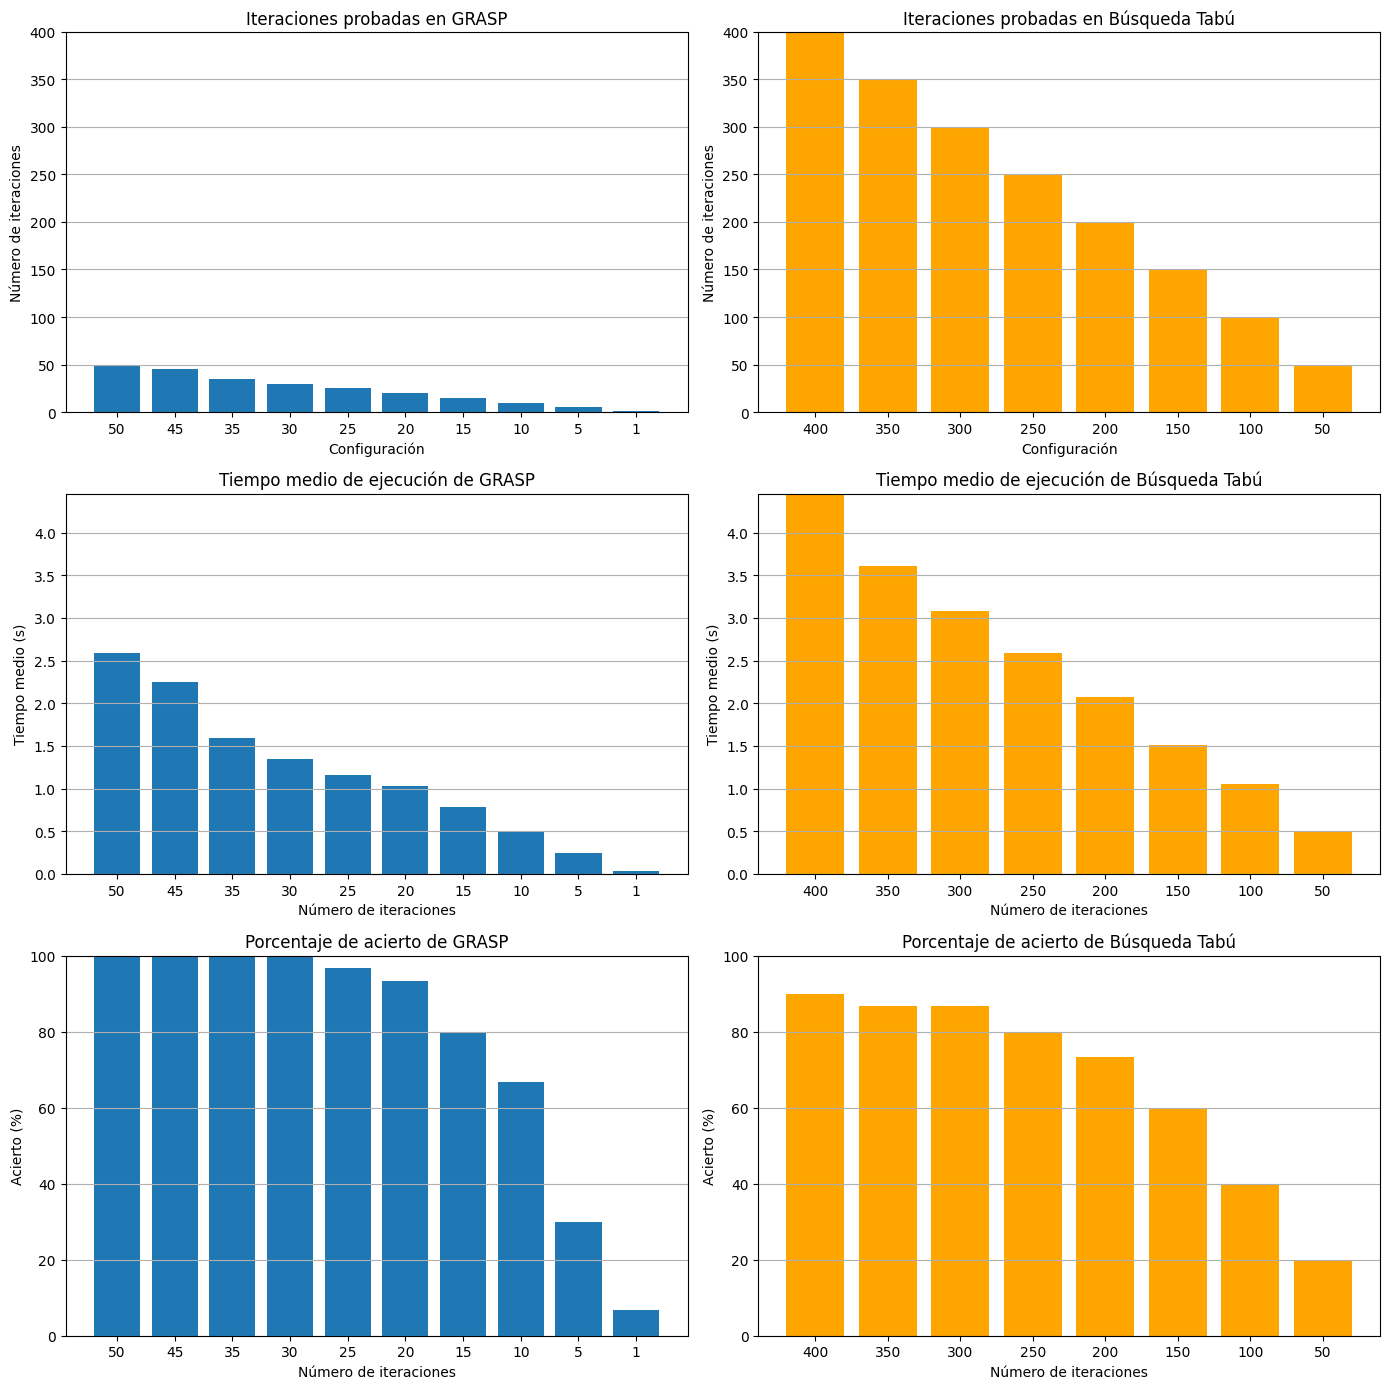

In [ ]:
# Ordeno de mayor a menor número de iteraciones
df_grasp_plot = df_resumen_grasp.sort_values("iteraciones", ascending=False).reset_index(drop=True)
df_tabu_plot = df_resumen_tabu.sort_values("iteraciones", ascending=False).reset_index(drop=True)

# Escalas comunes para comparar ambas gráficas de forma equivalente
max_iteraciones = max(df_grasp_plot["iteraciones"].max(), df_tabu_plot["iteraciones"].max())
max_tiempo = max(df_grasp_plot["tiempo_medio_seg"].max(), df_tabu_plot["tiempo_medio_seg"].max())

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Fila de gráficas 1: Número de iteraciones
axes[0, 0].bar(df_grasp_plot["iteraciones"].astype(str), df_grasp_plot["iteraciones"])
axes[0, 0].set_title("Iteraciones probadas en GRASP")
axes[0, 0].set_xlabel("Configuración")
axes[0, 0].set_ylabel("Número de iteraciones")
axes[0, 0].set_ylim(0, max_iteraciones)
axes[0, 0].grid(axis="y")

axes[0, 1].bar(df_tabu_plot["iteraciones"].astype(str), df_tabu_plot["iteraciones"], color="orange")
axes[0, 1].set_title("Iteraciones probadas en Búsqueda Tabú")
axes[0, 1].set_xlabel("Configuración")
axes[0, 1].set_ylabel("Número de iteraciones")
axes[0, 1].set_ylim(0, max_iteraciones)
axes[0, 1].grid(axis="y")

# Fila de gráficas 2: Tiempo medio
axes[1, 0].bar(df_grasp_plot["iteraciones"].astype(str), df_grasp_plot["tiempo_medio_seg"])
axes[1, 0].set_title("Tiempo medio de ejecución de GRASP")
axes[1, 0].set_xlabel("Número de iteraciones")
axes[1, 0].set_ylabel("Tiempo medio (s)")
axes[1, 0].set_ylim(0, max_tiempo)
axes[1, 0].grid(axis="y")

axes[1, 1].bar(df_tabu_plot["iteraciones"].astype(str), df_tabu_plot["tiempo_medio_seg"], color="orange")
axes[1, 1].set_title("Tiempo medio de ejecución de Búsqueda Tabú")
axes[1, 1].set_xlabel("Número de iteraciones")
axes[1, 1].set_ylabel("Tiempo medio (s)")
axes[1, 1].set_ylim(0, max_tiempo)
axes[1, 1].grid(axis="y")

# Fila de gráficas 3: POrcentaje de aciertos
axes[2, 0].bar(df_grasp_plot["iteraciones"].astype(str), df_grasp_plot["tasa_acierto"] * 100)
axes[2, 0].set_title("Porcentaje de acierto de GRASP")
axes[2, 0].set_xlabel("Número de iteraciones")
axes[2, 0].set_ylabel("Acierto (%)")
axes[2, 0].set_ylim(0, 100)
axes[2, 0].grid(axis="y")

axes[2, 1].bar(df_tabu_plot["iteraciones"].astype(str), df_tabu_plot["tasa_acierto"] * 100, color="orange")
axes[2, 1].set_title("Porcentaje de acierto de Búsqueda Tabú")
axes[2, 1].set_xlabel("Número de iteraciones")
axes[2, 1].set_ylabel("Acierto (%)")
axes[2, 1].set_ylim(0, 100)
axes[2, 1].grid(axis="y")



plt.tight_layout()
plt.show()

# **Conclusión final**

Analizando los resultados obtenidos llegamos a la conclusión de que, para este problema, el algoritmo que mejor se comporta es GRASP. Esto se debe a que alcanza porcentajes de acierto más altos, necesita menos iteraciones para llegar a buenas soluciones además de presentar tiempos de ejecución inferiores a los de la Búsqueda Tabú.

Probablemente esto se deba a la propia estructura del problema. En este caso, construir la solución de forma progresiva, intentando desde el principio agrupar tomas que compartan actores, parece ser una estrategia más adecuada que partir de una solución inicial y tratar de mejorarla después mediante movimientos locales. Es decir, en este problema parece más efectivo construir bien desde el principio que depender tanto de la fase de exploración posterior.

Por tanto, aunque ambos algoritmos resultan válidos para abordar el problema, los resultados muestran de forma bastante clara que GRASP es la opción más adecuada para este caso concreto al compararla a la búsqueda tabú.